# 02 — Data Cleaning & Feature Engineering
## AI Adoption in U.S. Small and Medium Enterprises (2019–2024)

---

This notebook handles all data quality steps before analysis:
- Missing value detection and treatment
- Outlier detection and capping
- Data type corrections
- Feature engineering (new derived columns)
- Categorical encoding
- Saving the cleaned dataset to `../data/processed/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.4f}'.format)

print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Raw Data

In [2]:
# ── Load main dataset ────────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/sme_ai_adoption_main.csv')

# Store original shape for final comparison
original_shape = df.shape
original_cols  = list(df.columns)

print(f'Raw data loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Raw data loaded: 5,000 rows x 22 columns


,company_id,year,state,industry,size_category,employees,revenue_m_usd,tech_invest_pct,tech_invest_usd,tech_emp_pct,years_in_business,founded_year,cloud_adopted,has_data_strategy,ceo_tech_background,digital_maturity,ai_adopted,ai_tools_count,ai_investment_usd,productivity_gain_pct,revenue_growth_pct,primary_barrier
0,SME_00001,2022,North Carolina,Hospitality & Food,Micro (1-9),3,0.0500,0.0185,925.0000,0.0468,23,1999,1,0,0,2.9500,0,0,0.0000,0.0000,8.9600,Lack of expertise
1,SME_00002,2022,California,Agriculture,Upper-Mid (250-500),264,13.9940,0.0526,"736,499.0000",0.1613,32,1990,1,0,1,4.6400,0,0,0.0000,0.0000,9.4700,Data quality
2,SME_00003,2021,North Carolina,Education,Medium (50-249),84,1.3180,0.0581,"76,504.0000",0.0485,34,1987,1,1,1,5.3400,0,0,0.0000,0.0000,-7.9400,Security concerns


---
## 2. Missing Value Analysis

In [3]:
# ── Count missing values per column ─────────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct'  : missing_pct
}).sort_values('missing_count', ascending=False)

print('Missing values per column:')
print(missing_df[missing_df['missing_count'] > 0].to_string())
print(f'\nColumns with NO missing values: {(missing_count == 0).sum()}')

Missing values per column:
                 missing_count  missing_pct
primary_barrier           2161      43.2200

Columns with NO missing values: 21


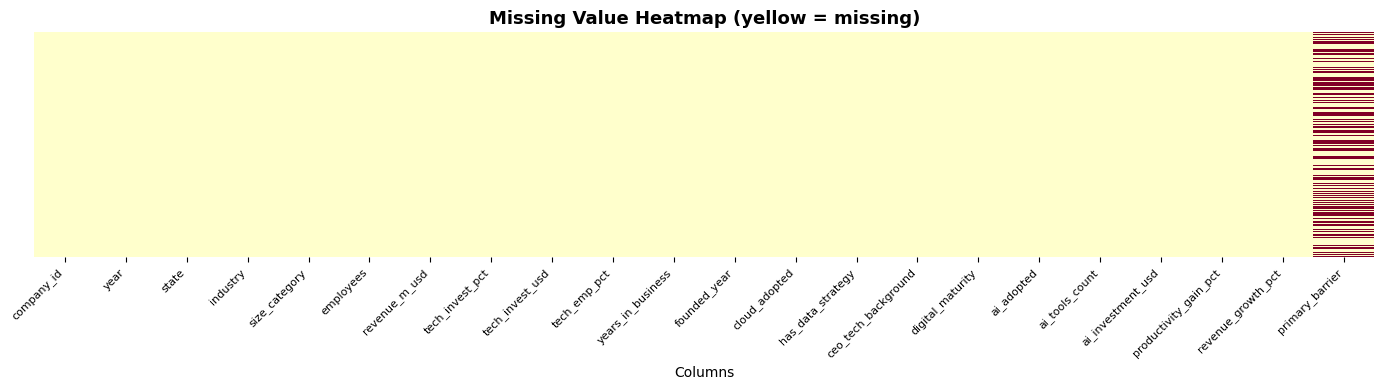


Note: If no yellow appears, the dataset has no missing values.


In [4]:
# ── Missing value heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='YlOrRd',
    ax=ax
)
ax.set_title('Missing Value Heatmap (yellow = missing)', fontsize=13, fontweight='bold')
ax.set_xlabel('Columns', fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()
print('\nNote: If no yellow appears, the dataset has no missing values.')

In [5]:
# ── Percentage table of missingness ─────────────────────────────────────────
pct_table = pd.DataFrame({
    'Column'           : df.columns,
    'Non-Null Count'   : df.notnull().sum().values,
    'Null Count'       : df.isnull().sum().values,
    'Null Percentage'  : (df.isnull().sum() / len(df) * 100).round(2).values,
    'Dtype'            : df.dtypes.values.astype(str)
})
pct_table

,Column,Non-Null Count,Null Count,Null Percentage,Dtype
0,company_id,5000,0,0.0000,object
1,year,5000,0,0.0000,int64
2,state,5000,0,0.0000,object
3,industry,5000,0,0.0000,object
4,size_category,5000,0,0.0000,object
5,employees,5000,0,0.0000,int64
6,revenue_m_usd,5000,0,0.0000,float64
7,tech_invest_pct,5000,0,0.0000,float64
8,tech_invest_usd,5000,0,0.0000,float64
9,tech_emp_pct,5000,0,0.0000,float64


---
## 3. Outlier Detection (IQR Method)

In [6]:
def iqr_bounds(series):
    """Return (lower_bound, upper_bound) using 1.5*IQR rule."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper


outlier_cols = ['revenue_m_usd', 'employees', 'ai_investment_usd']

print('IQR Outlier Summary (before capping):')
print('-' * 60)
for col in outlier_cols:
    lo, hi = iqr_bounds(df[col])
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'  {col:<25}  lower={lo:>10.1f}  upper={hi:>12.1f}  outliers={n_out}')

IQR Outlier Summary (before capping):
------------------------------------------------------------
  revenue_m_usd              lower=      -3.3  upper=         6.0  outliers=675
  employees                  lower=     -59.5  upper=       112.5  outliers=936
  ai_investment_usd          lower=  -17955.8  upper=     29926.2  outliers=845


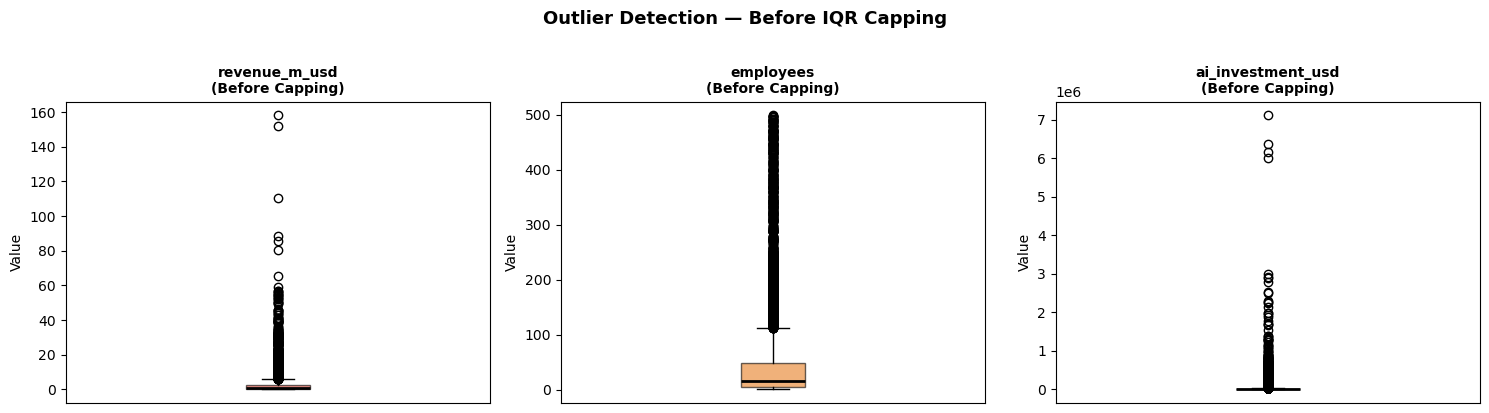

In [7]:
# ── Box plots BEFORE capping ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_before = ['#E74C3C', '#E67E22', '#8E44AD']

for ax, col, color in zip(axes, outlier_cols, colors_before):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{col}\n(Before Capping)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])

plt.suptitle('Outlier Detection — Before IQR Capping', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# ── Cap outliers at IQR bounds ───────────────────────────────────────────────
for col in outlier_cols:
    lo, hi = iqr_bounds(df[col])
    # Clip to bounds (keep lower at 0 minimum for monetary/count columns)
    lo_clip = max(lo, 0)
    df[col] = df[col].clip(lower=lo_clip, upper=hi)
    print(f'  Capped {col} to [{lo_clip:.1f}, {hi:.1f}]')

  Capped revenue_m_usd to [0.0, 6.0]
  Capped employees to [0.0, 112.5]
  Capped ai_investment_usd to [0.0, 29926.2]


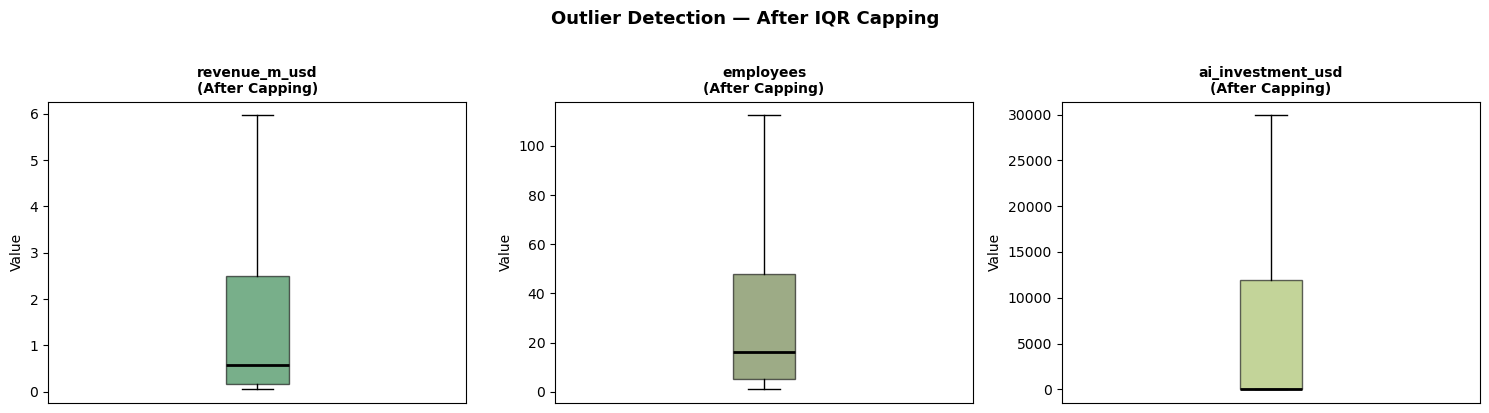

In [9]:
# ── Box plots AFTER capping ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_after = ['#1F7A3C', '#5C7435', '#9BB855']

for ax, col, color in zip(axes, outlier_cols, colors_after):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{col}\n(After Capping)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xticks([])

plt.suptitle('Outlier Detection — After IQR Capping', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Data Type Corrections

In [10]:
print('Data types BEFORE corrections:')
print(df.dtypes)
print()

Data types BEFORE corrections:
company_id                object
year                       int64
state                     object
industry                  object
size_category             object
employees                float64
revenue_m_usd            float64
tech_invest_pct          float64
tech_invest_usd          float64
tech_emp_pct             float64
years_in_business          int64
founded_year               int64
cloud_adopted              int64
has_data_strategy          int64
ceo_tech_background        int64
digital_maturity         float64
ai_adopted                 int64
ai_tools_count             int64
ai_investment_usd        float64
productivity_gain_pct    float64
revenue_growth_pct       float64
primary_barrier           object
dtype: object



In [11]:
# ── Enforce correct types ────────────────────────────────────────────────────

# Integer columns
int_cols = ['year', 'employees', 'ai_tools_count', 'years_in_business',
            'founded_year', 'cloud_adopted', 'has_data_strategy',
            'ceo_tech_background', 'ai_adopted']
for col in int_cols:
    df[col] = df[col].astype(int)

# Float columns (already float, but ensure)
float_cols = ['revenue_m_usd', 'tech_invest_pct', 'tech_invest_usd',
              'tech_emp_pct', 'digital_maturity', 'ai_investment_usd',
              'productivity_gain_pct', 'revenue_growth_pct']
for col in float_cols:
    df[col] = df[col].astype(float)

# String columns
str_cols = ['company_id', 'state', 'industry', 'size_category', 'primary_barrier']
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

print('Data types AFTER corrections:')
print(df.dtypes)

Data types AFTER corrections:
company_id                object
year                       int64
state                     object
industry                  object
size_category             object
employees                  int64
revenue_m_usd            float64
tech_invest_pct          float64
tech_invest_usd          float64
tech_emp_pct             float64
years_in_business          int64
founded_year               int64
cloud_adopted              int64
has_data_strategy          int64
ceo_tech_background        int64
digital_maturity         float64
ai_adopted                 int64
ai_tools_count             int64
ai_investment_usd        float64
productivity_gain_pct    float64
revenue_growth_pct       float64
primary_barrier           object
dtype: object


---
## 5. Feature Engineering

### 5.1 Numeric Derived Features

In [12]:
# ── Revenue per employee ─────────────────────────────────────────────────────
# Converts revenue from millions to dollars, then divides by headcount
df['revenue_per_employee'] = (df['revenue_m_usd'] * 1e6) / df['employees']

# ── AI investment per employee (0 for non-adopters) ─────────────────────────
df['ai_investment_per_employee'] = np.where(
    df['ai_adopted'] == 1,
    df['ai_investment_usd'] / df['employees'],
    0
)

# ── Tech investment in thousands USD ────────────────────────────────────────
df['tech_invest_k_usd'] = df['tech_invest_usd'] / 1000

print('Numeric features created: revenue_per_employee, ai_investment_per_employee, tech_invest_k_usd')
df[['revenue_per_employee', 'ai_investment_per_employee', 'tech_invest_k_usd']].describe()

Numeric features created: revenue_per_employee, ai_investment_per_employee, tech_invest_k_usd


,revenue_per_employee,ai_investment_per_employee,tech_invest_k_usd
count,"5,000.0000","5,000.0000","5,000.0000"
mean,"49,442.2815",571.5844,162.4695
std,"38,868.6186","1,436.6197",463.5131
min,"3,085.7143",0.0000,0.2500
25%,"23,607.3171",0.0000,4.8338
50%,"43,000.0000",0.0000,19.4175
75%,"56,000.0000",490.6905,98.5265
max,"410,750.0000","21,998.0000","8,553.1490"


### 5.2 Ordinal Size Encoding

In [13]:
# ── Ordinal mapping: size category → integer ─────────────────────────────────
size_map = {
    'Micro (1-9)'       : 1,
    'Small (10-49)'     : 2,
    'Medium (50-249)'   : 3,
    'Upper-Mid (250-500)': 4
}
df['size_num'] = df['size_category'].map(size_map)

print('size_category → size_num mapping:')
print(df[['size_category', 'size_num']].drop_duplicates().sort_values('size_num'))

size_category → size_num mapping:
         size_category  size_num
0          Micro (1-9)         1
3        Small (10-49)         2
2      Medium (50-249)         3
1  Upper-Mid (250-500)         4


### 5.3 Geographic Region Mapping

In [14]:
# ── Map US states to 5 census-style regions ──────────────────────────────────
region_map = {
    # Northeast
    'Maine': 'Northeast', 'New Hampshire': 'Northeast', 'Vermont': 'Northeast',
    'Massachusetts': 'Northeast', 'Rhode Island': 'Northeast', 'Connecticut': 'Northeast',
    'New York': 'Northeast', 'New Jersey': 'Northeast', 'Pennsylvania': 'Northeast',
    # Southeast
    'Delaware': 'Southeast', 'Maryland': 'Southeast', 'Virginia': 'Southeast',
    'West Virginia': 'Southeast', 'North Carolina': 'Southeast', 'South Carolina': 'Southeast',
    'Georgia': 'Southeast', 'Florida': 'Southeast', 'Kentucky': 'Southeast',
    'Tennessee': 'Southeast', 'Alabama': 'Southeast', 'Mississippi': 'Southeast',
    'Arkansas': 'Southeast', 'Louisiana': 'Southeast', 'District of Columbia': 'Southeast',
    # Midwest
    'Ohio': 'Midwest', 'Indiana': 'Midwest', 'Illinois': 'Midwest',
    'Michigan': 'Midwest', 'Wisconsin': 'Midwest', 'Minnesota': 'Midwest',
    'Iowa': 'Midwest', 'Missouri': 'Midwest', 'North Dakota': 'Midwest',
    'South Dakota': 'Midwest', 'Nebraska': 'Midwest', 'Kansas': 'Midwest',
    # Southwest
    'Texas': 'Southwest', 'Oklahoma': 'Southwest', 'New Mexico': 'Southwest',
    'Arizona': 'Southwest',
    # West
    'Montana': 'West', 'Idaho': 'West', 'Wyoming': 'West', 'Colorado': 'West',
    'Utah': 'West', 'Nevada': 'West', 'Washington': 'West', 'Oregon': 'West',
    'California': 'West', 'Alaska': 'West', 'Hawaii': 'West'
}

df['region'] = df['state'].map(region_map).fillna('Other')

print('Region distribution:')
print(df['region'].value_counts())

Region distribution:
region
Midwest      1653
Southeast    1231
West         1119
Northeast     603
Southwest     394
Name: count, dtype: int64


### 5.4 Post-ChatGPT Flag & AI Readiness Score

In [15]:
# ── Post-ChatGPT era flag (Nov 2022 launch → meaningful from 2023 surveys) ───
df['post_chatgpt'] = (df['year'] >= 2023).astype(int)

print('post_chatgpt distribution:')
print(df['post_chatgpt'].value_counts().rename({0: 'Pre-ChatGPT era', 1: 'Post-ChatGPT era'}))

post_chatgpt distribution:
post_chatgpt
Pre-ChatGPT era     2741
Post-ChatGPT era    2259
Name: count, dtype: int64


In [16]:
# ── AI Readiness Score (composite 0–1 scale) ─────────────────────────────────
# Weights:
#   30% → digital_maturity normalized to 0-1  (divide by 10)
#   25% → cloud_adopted  (already binary 0/1)
#   20% → has_data_strategy  (already binary 0/1)
#   15% → tech_invest_pct * 10  (scale: 0.1 of revenue = 1.0 component)
#   10% → tech_emp_pct * 5  (scale: 20% tech workforce = 1.0 component)

df['ai_readiness_score'] = (
    0.30 * (df['digital_maturity'] / 10) +
    0.25 * df['cloud_adopted'] +
    0.20 * df['has_data_strategy'] +
    0.15 * (df['tech_invest_pct'] * 10).clip(0, 1) +
    0.10 * (df['tech_emp_pct'] * 5).clip(0, 1)
)

print('AI Readiness Score summary:')
print(df['ai_readiness_score'].describe())
print(f'\nMean score for AI adopters     : {df.loc[df["ai_adopted"]==1, "ai_readiness_score"].mean():.3f}')
print(f'Mean score for non-AI adopters : {df.loc[df["ai_adopted"]==0, "ai_readiness_score"].mean():.3f}')

AI Readiness Score summary:
count   5,000.0000
mean        0.4608
std         0.1827
min         0.0692
25%         0.3238
50%         0.4578
75%         0.5988
max         0.9949
Name: ai_readiness_score, dtype: float64

Mean score for AI adopters     : 0.507
Mean score for non-AI adopters : 0.426


---
## 6. Categorical Encoding

In [17]:
# ── LabelEncoder for categorical columns ────────────────────────────────────
# Original categories are preserved; encoded versions get '_enc' suffix

le = LabelEncoder()
encode_cols = ['industry', 'state', 'region', 'size_category', 'primary_barrier']

label_mappings = {}

for col in encode_cols:
    encoded_col = col + '_enc'
    df[encoded_col] = le.fit_transform(df[col])
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'{col:20} → {encoded_col} ({df[col].nunique()} unique categories)')

print('\nSample mapping for industry:')
for k, v in label_mappings['industry'].items():
    print(f'  {k:<30} → {v}')

industry             → industry_enc (10 unique categories)
state                → state_enc (30 unique categories)
region               → region_enc (5 unique categories)
size_category        → size_category_enc (4 unique categories)
primary_barrier      → primary_barrier_enc (7 unique categories)

Sample mapping for industry:
  Agriculture                    → 0
  Construction                   → 1
  Education                      → 2
  Finance & Insurance            → 3
  Healthcare & Biotech           → 4
  Hospitality & Food             → 5
  Manufacturing                  → 6
  Professional Services          → 7
  Retail & E-commerce            → 8
  Technology & Software          → 9


---
## 7. Save Cleaned Data

In [18]:
# ── Save to processed folder ─────────────────────────────────────────────────
output_path = '../data/processed/sme_clean.csv'
df.to_csv(output_path, index=False)

print(f'Cleaned dataset saved to: {output_path}')
print(f'Final shape: {df.shape}')

Cleaned dataset saved to: ../data/processed/sme_clean.csv
Final shape: (5000, 34)


---
## 8. Summary

In [19]:
# ── Before/After comparison ──────────────────────────────────────────────────
new_features = [
    'revenue_per_employee',
    'ai_investment_per_employee',
    'tech_invest_k_usd',
    'size_num',
    'region',
    'post_chatgpt',
    'ai_readiness_score',
    'industry_enc',
    'state_enc',
    'region_enc',
    'size_category_enc',
    'primary_barrier_enc',
]

print('=' * 55)
print('  CLEANING SUMMARY')
print('=' * 55)
print(f'  Rows before    : {original_shape[0]:,}')
print(f'  Rows after     : {df.shape[0]:,}  (no rows dropped)')
print(f'  Columns before : {original_shape[1]}')
print(f'  Columns after  : {df.shape[1]}')
print(f'  New features   : {len(new_features)}')
print()
print('  New features added:')
for feat in new_features:
    print(f'    + {feat}')
print('=' * 55)

  CLEANING SUMMARY
  Rows before    : 5,000
  Rows after     : 5,000  (no rows dropped)
  Columns before : 22
  Columns after  : 34
  New features   : 12

  New features added:
    + revenue_per_employee
    + ai_investment_per_employee
    + tech_invest_k_usd
    + size_num
    + region
    + post_chatgpt
    + ai_readiness_score
    + industry_enc
    + state_enc
    + region_enc
    + size_category_enc
    + primary_barrier_enc
